In [1]:
import os, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from py_util_dx.py_utils import setProjectPath
from scipy.stats import ttest_ind, ttest_1samp
from evaluations import *
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
from visualizations import flatmap_real_vals, plot_flatmap_labels
from nitools.cifti import surf_from_cifti
from py_util_dx.data_utils import get_roi_vtx_from_fs32k
from scipy.spatial.distance import pdist


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/traitlets/config/application.py",

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()
dataset_name = 'MDTB' # or Demand
# atlas_name = 'glasser'
atlas_name = 'schaefer100'
# atlas_name = 'yeo17'
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, 'START_A4_parcellation_evaluation', f'{dataset_name}', atlas_name)
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

In [4]:
atlas_str = 'fs32k'
atlas, ainf = am.get_atlas(atlas_str)

In [5]:
# ROIs = ['PFC', 'parietal', 'visual', 'somatosensory'] 
ROIs = ['PFC'] 
n_rois = len(ROIs) 
example_subjIs = np.arange(24)
# example_subjIs = [0, 7]
n_example_subjects = len(example_subjIs) 
frames_dict = {
    'PFC': [[-210, 25, -90, 140], [0, 240, -110, 120]], 
    'visual': [[100, 230, -70, 160], [-250, -50, -70, 130]], 
    'somatosensory':[[-10, 80, -10, 160], [-60, 30, -10, 140]], 
    'parietal': [[20, 140, 0, 160], [-140, -30, 0, 160]]
}
gridspec_dict = {
    'PFC': [-0.2, -0.05],
    'visual': [-0.2, -0.12],
    'parietal': [-0.55, -0.25],
    'somatosensory': [-0.55, -0.05]
}

/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_9222/2061506285.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_9222/2061506285.py:39: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_9222/2061506285.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_9222/2061506285.py:39: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_9222/2061506285.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/hv/x8n5hv816wl3ld__pv8x18vm00

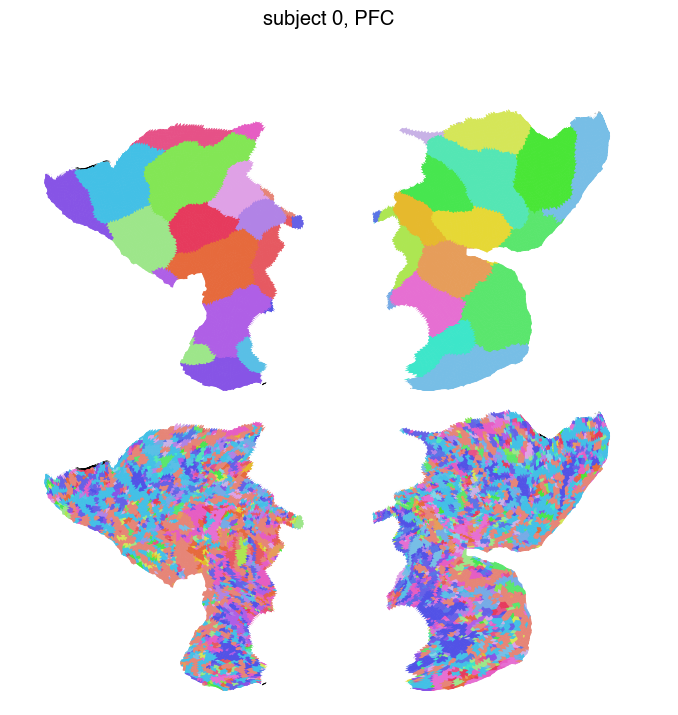

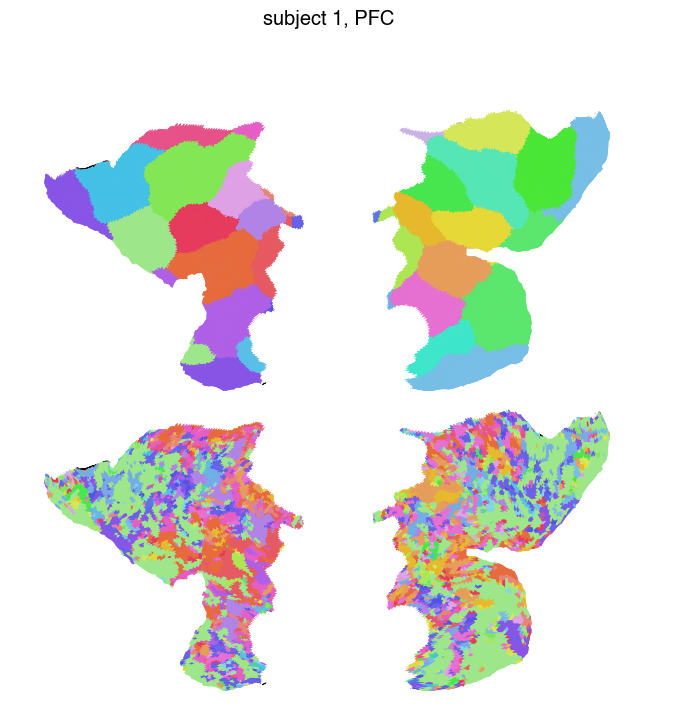

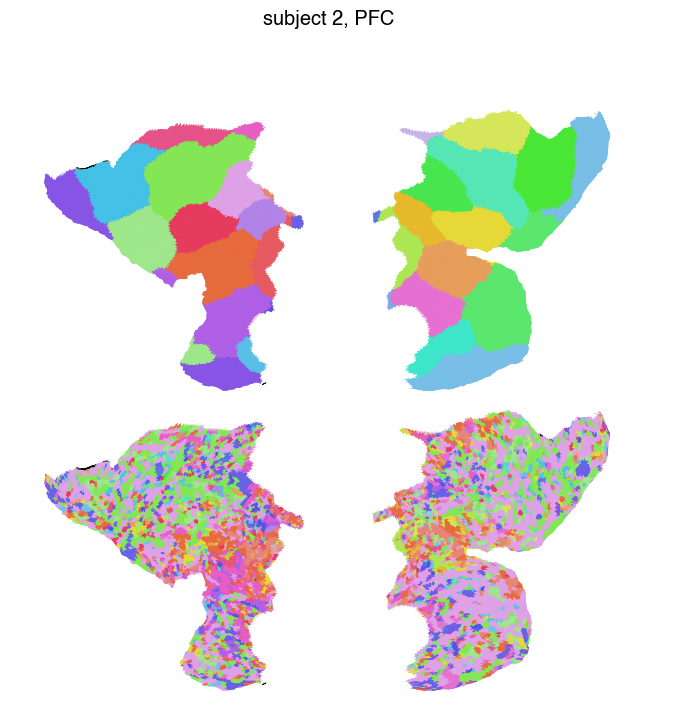

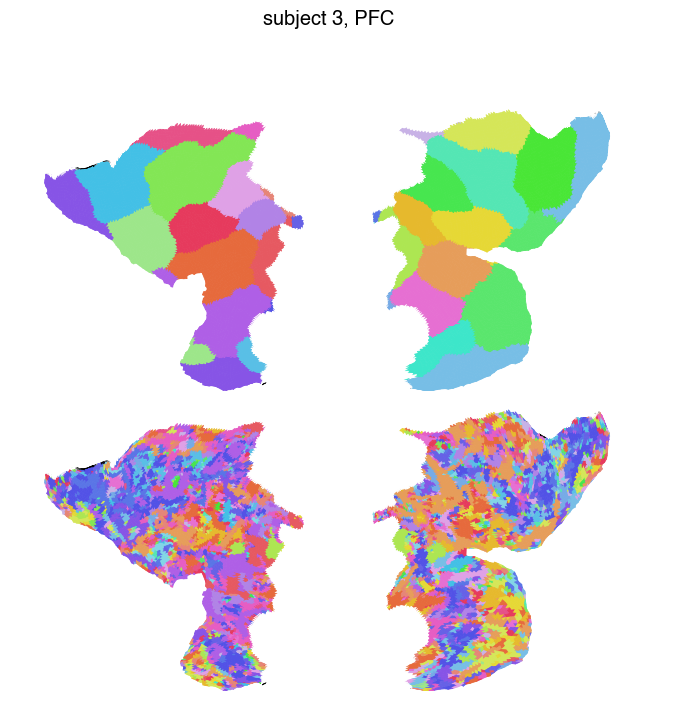

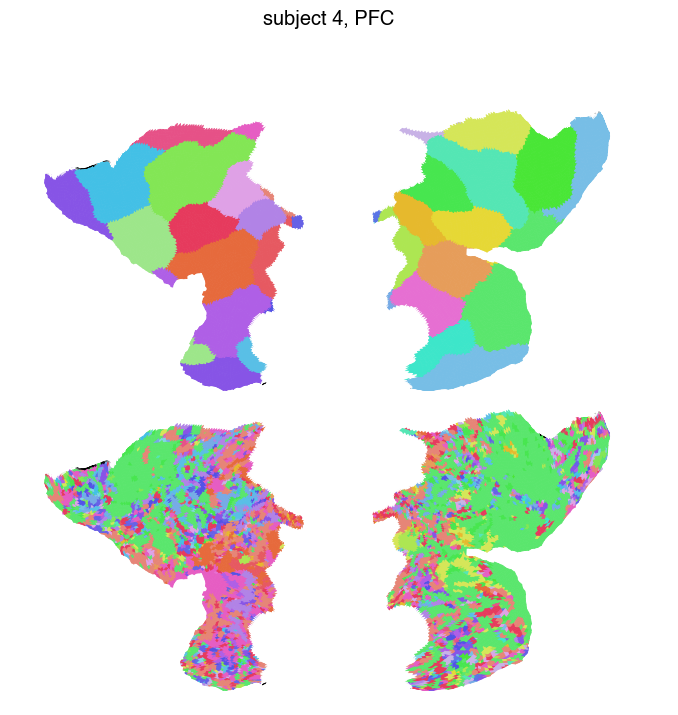

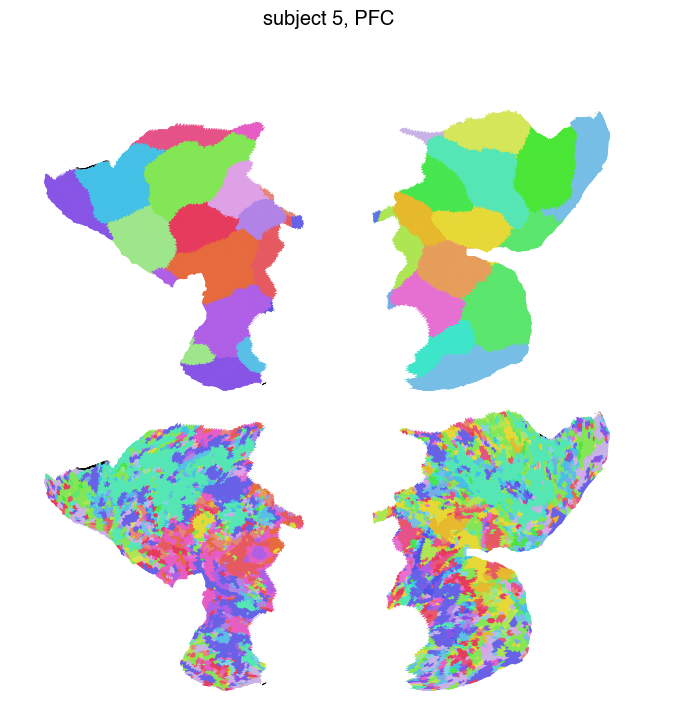

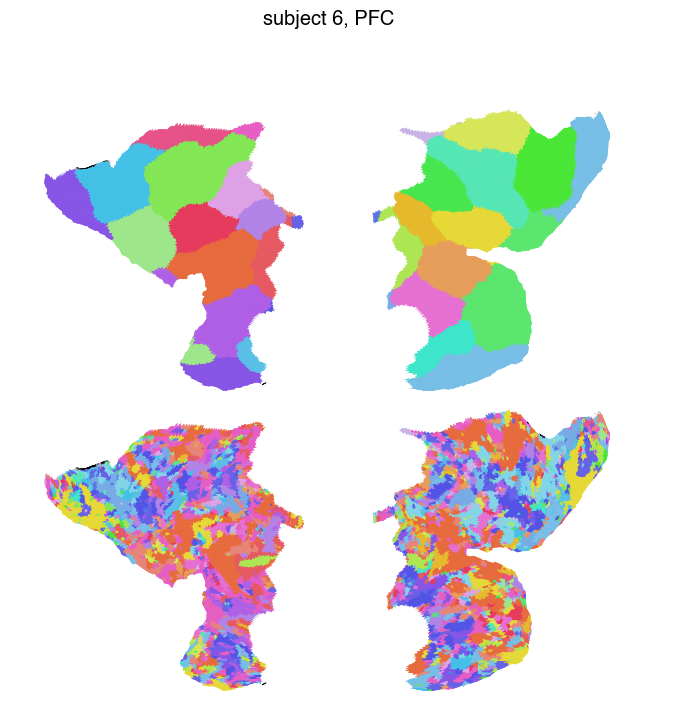

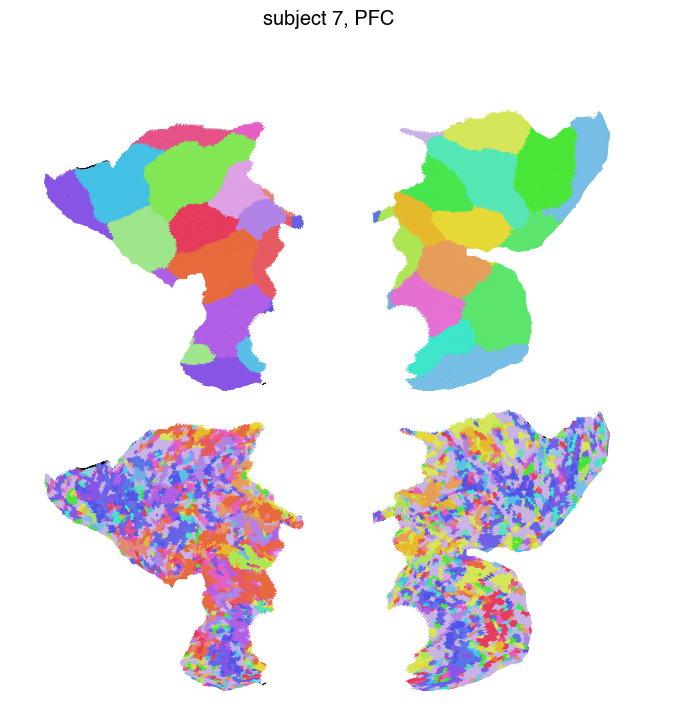

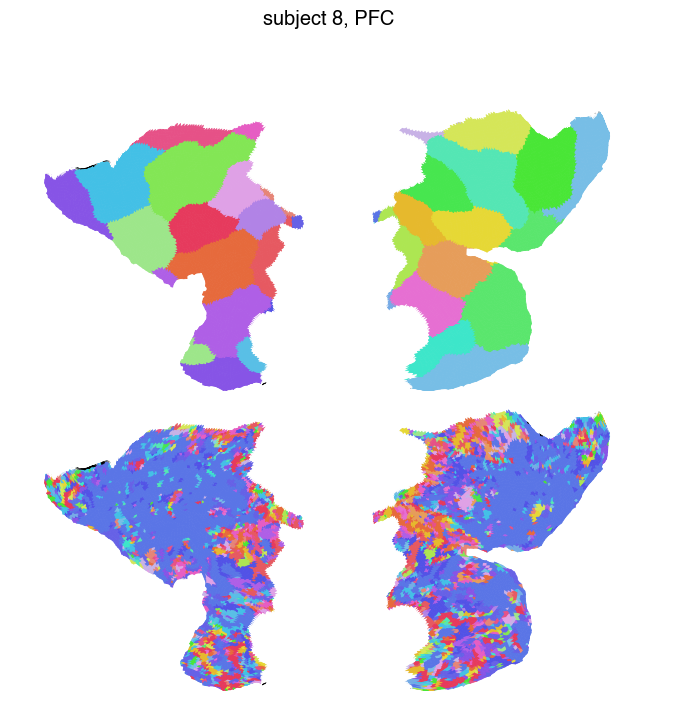

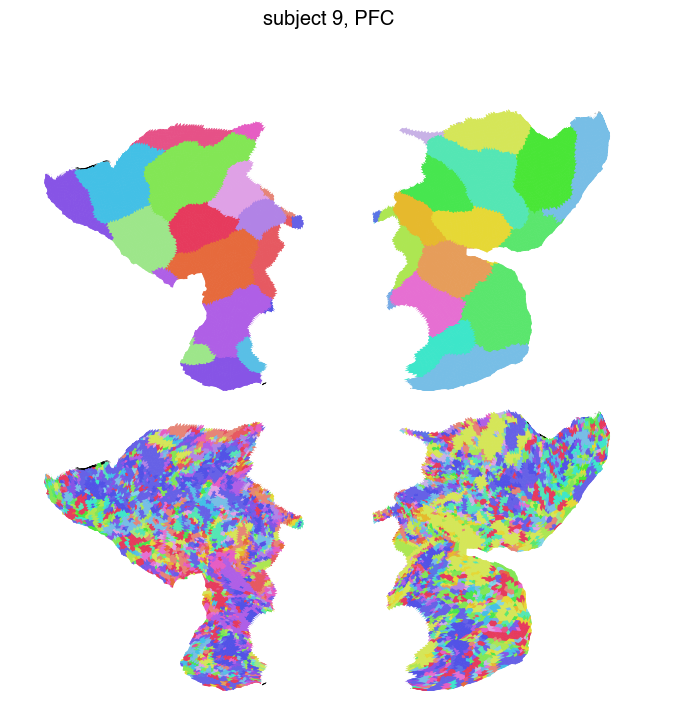

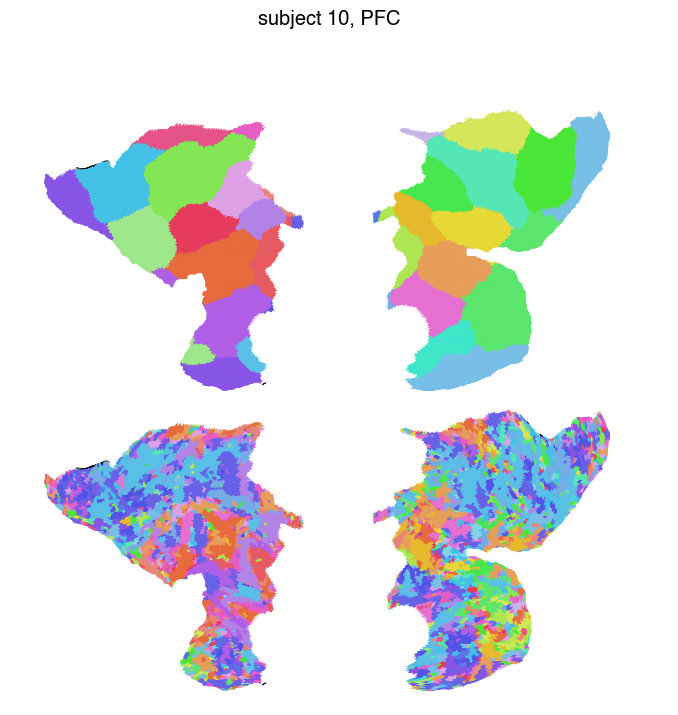

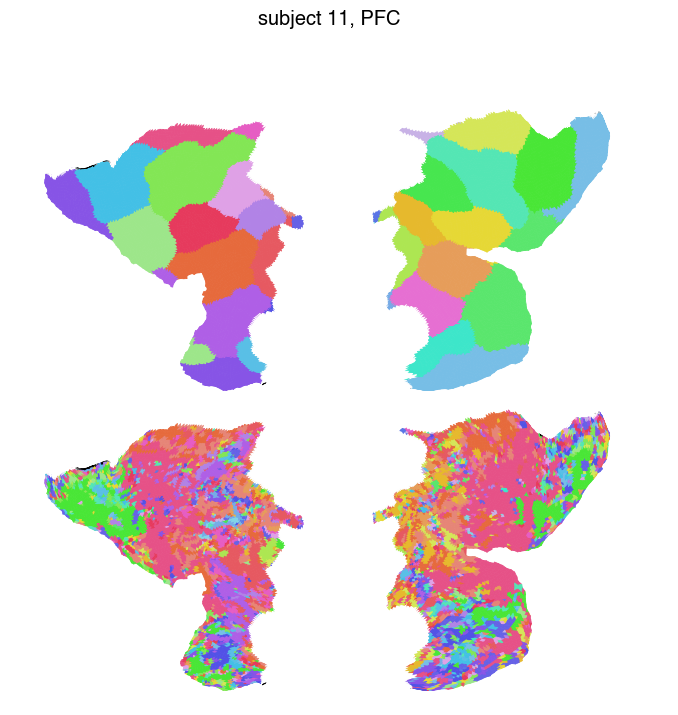

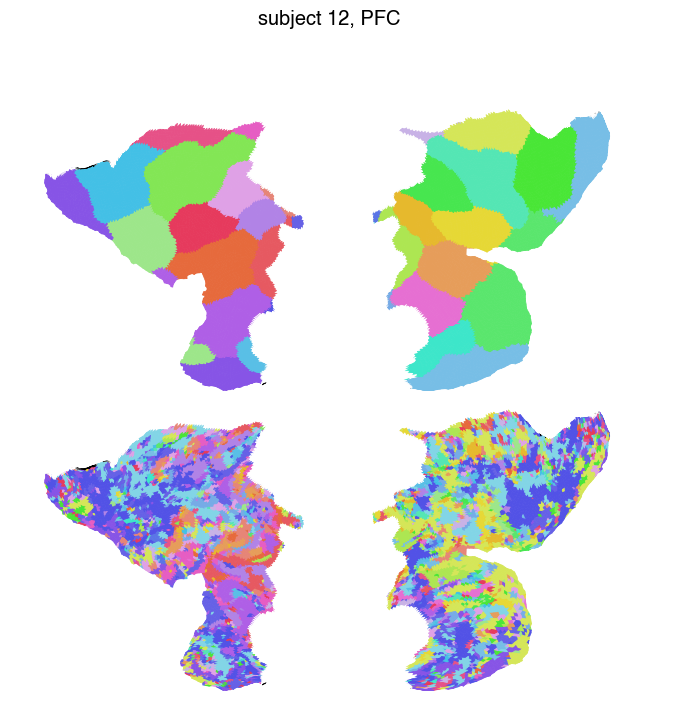

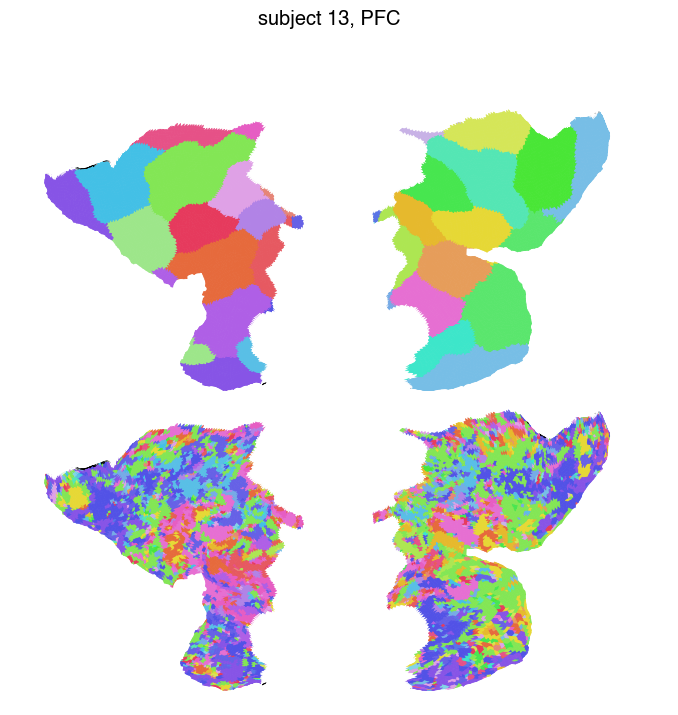

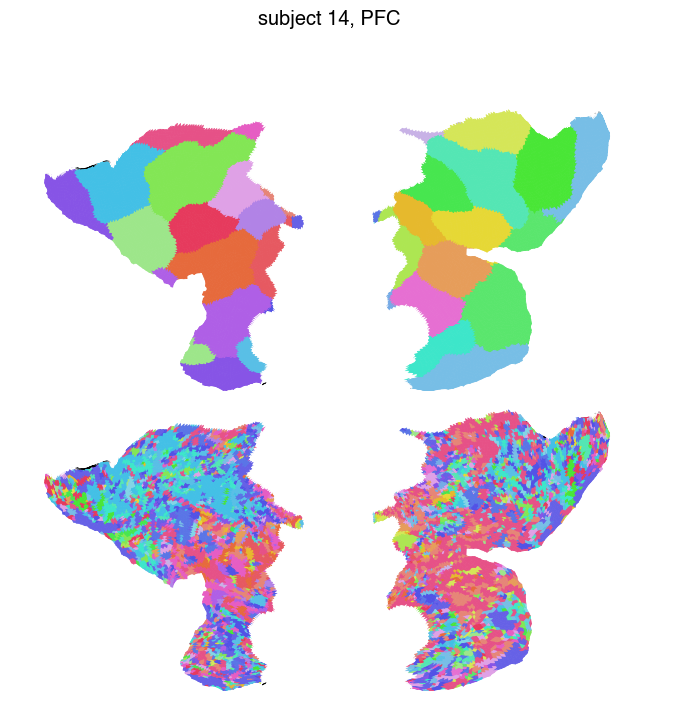

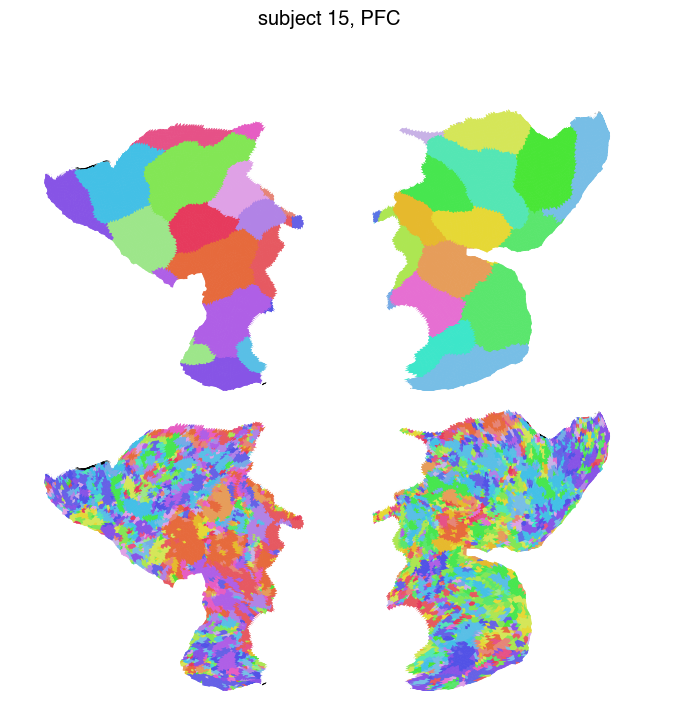

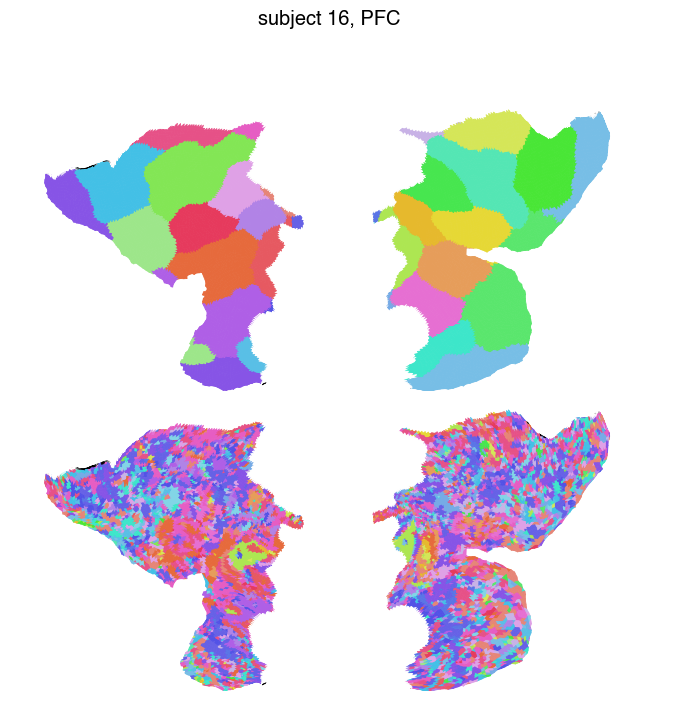

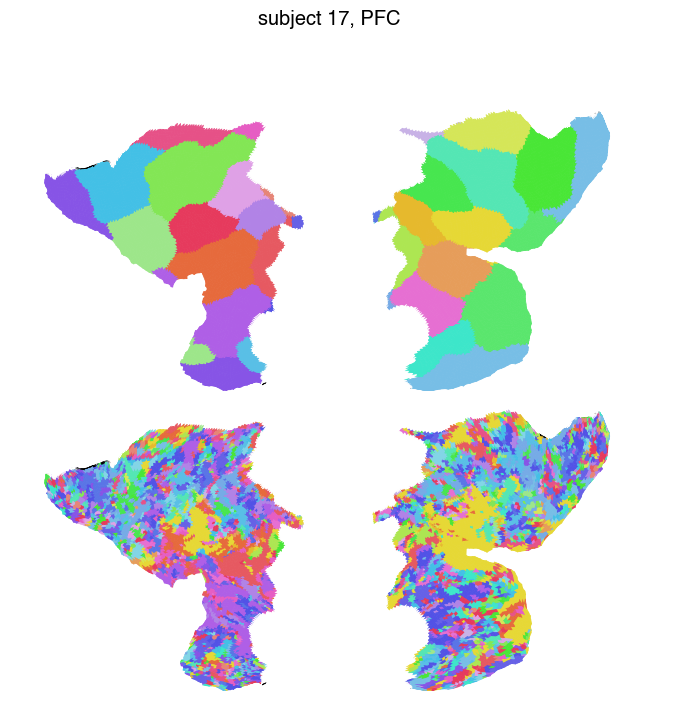

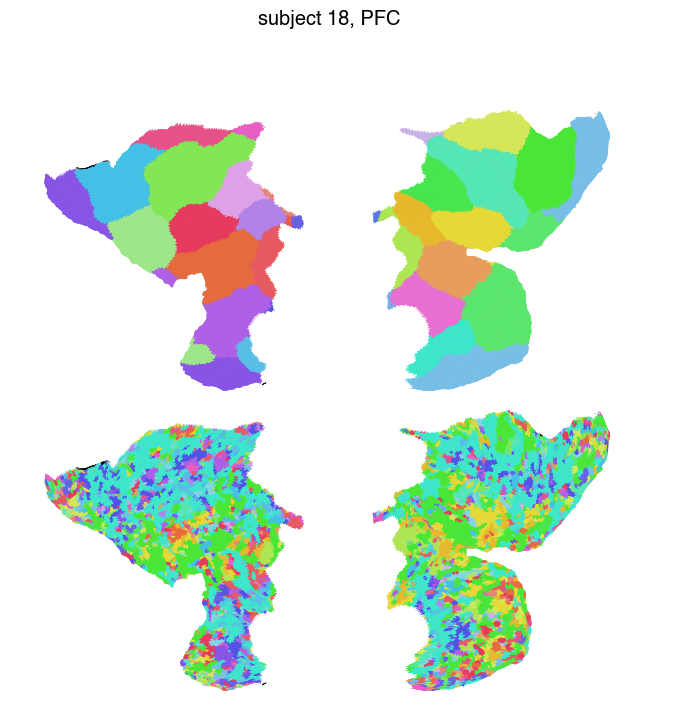

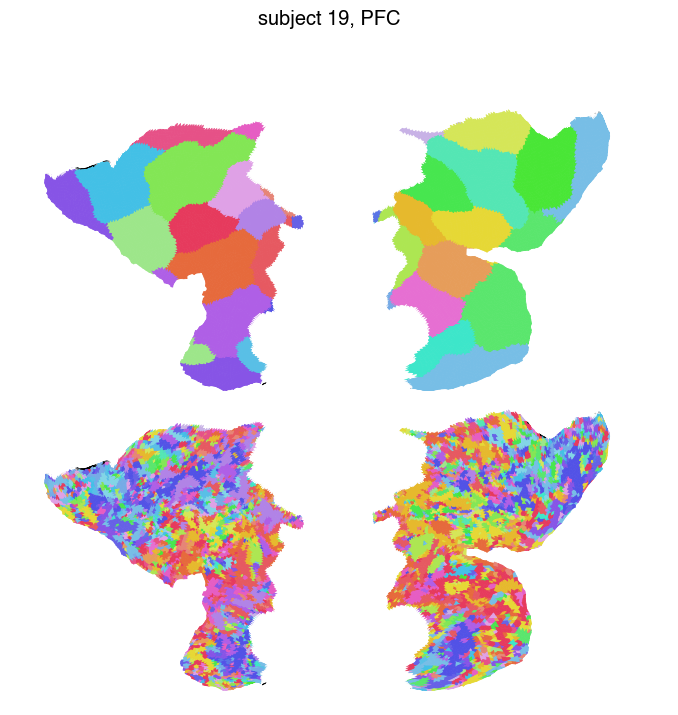

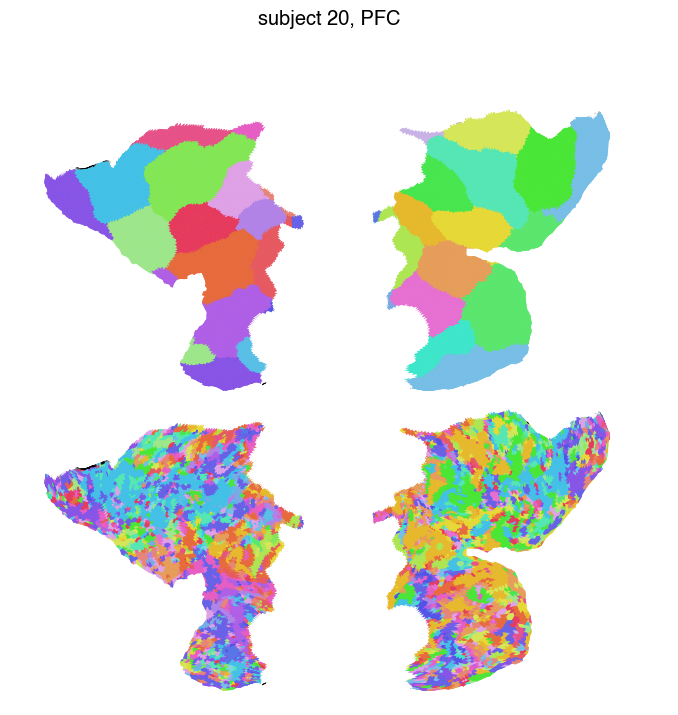

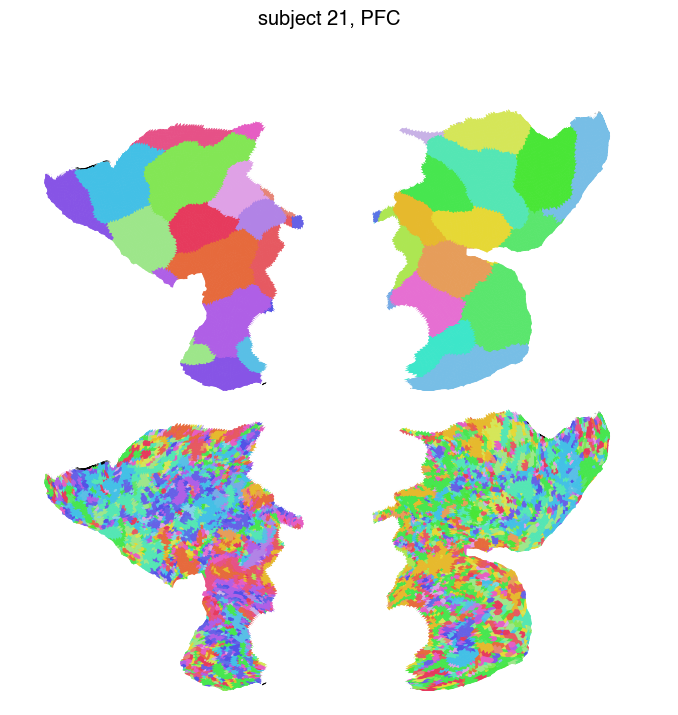

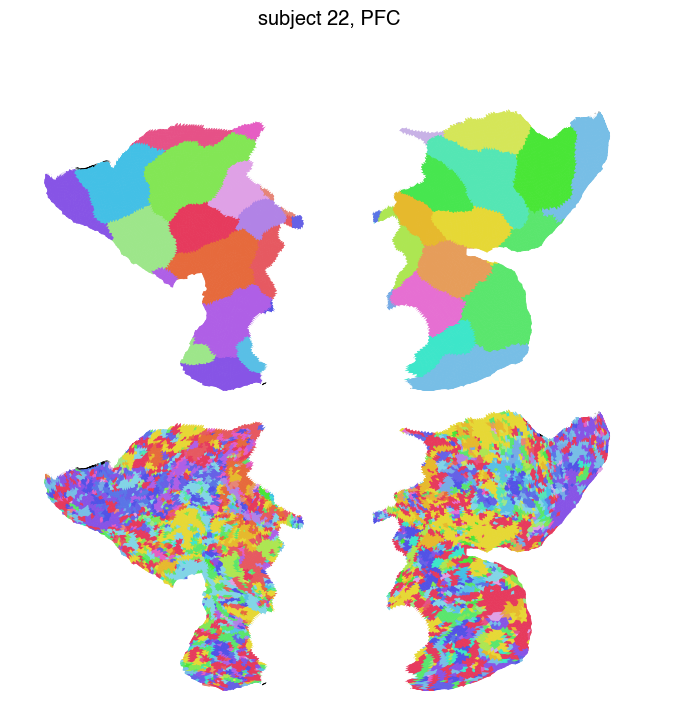

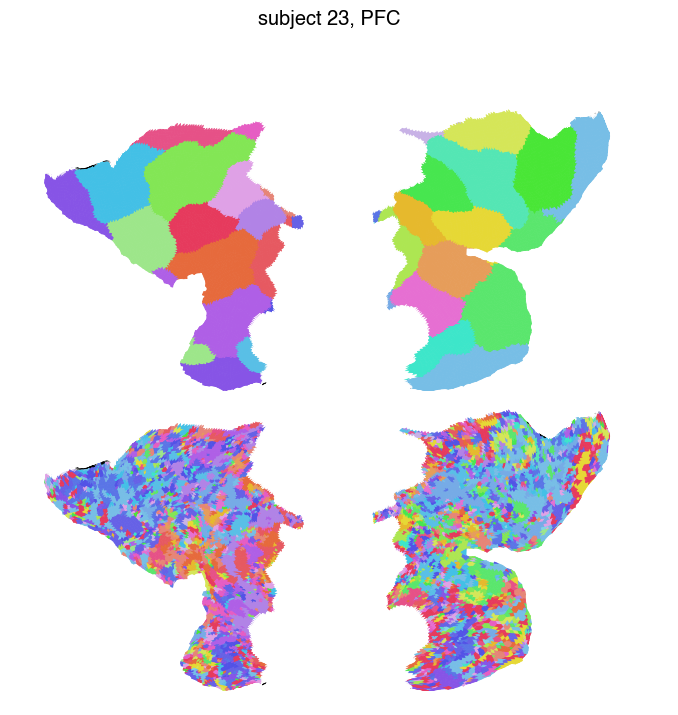

In [6]:
for roiI, roi in enumerate(ROIs):
    PKL_individualized_parcellation = os.path.join(projectPath, 'results', 'START_A3_bayes_parcellation', f'{dataset_name}', atlas_name, f'output_{roi}.pkl')
    with open(PKL_individualized_parcellation, 'rb') as pf:
        output_indiv = pickle.load(pf)
        labels_in_group = output_indiv['labels_in_group']
        parcel_names_in_group = output_indiv['parcel_names_in_group']

        U_individual = output_indiv['U_individual']     # data only parcellation
        indiv_parcellation = output_indiv['indiv_parcellation']

        U_group = output_indiv['U_group']
        group_parcellation = output_indiv['group_parcellation']

        group_parcellation[group_parcellation==0] = np.max(group_parcellation)

    for subjI in example_subjIs:
        # fig, ax = plt.subplots(2, 2)
        fig, ax = plt.subplots(2, 2, figsize=(full_width, 8), constrained_layout=True, gridspec_kw={'wspace': gridspec_dict[roi][0], 'hspace': gridspec_dict[roi][1]})
        fig.set_figwidth(full_width)

        # first plot group atlas 
        [label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(group_parcellation.reshape(1, -1)))
        plt.axes(ax[0, 0])
        plot_flatmap_labels(label_L, 'L', frame=frames_dict[roi][0], borders=None, atlas=atlas_name)

        plt.axes(ax[0, 1])
        plot_flatmap_labels(label_R, 'R', frame=frames_dict[roi][1], borders=None, atlas=atlas_name)

        [label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(indiv_parcellation[subjI].reshape(1, -1)))
        plt.axes(ax[1, 0])
        plot_flatmap_labels(label_L, 'L', frame=frames_dict[roi][0], borders=None, atlas=atlas_name)
        # plot_flatmap_labels(label_L, 'L', frame=None, borders=None) 
        
        plt.axes(ax[1, 1])
        plot_flatmap_labels(label_R, 'R', frame=frames_dict[roi][1], borders=None, atlas=atlas_name)
        # plot_flatmap_labels(label_R, 'R', frame=None, borders=None)  

        plt.suptitle(f'subject {subjI}, {roi}')
        plt.tight_layout() 

        JPG_fig = os.path.join(resultsPath, f'example_atlas_{roi}_subject_{subjI}.jpg')
        plt.savefig(JPG_fig, dpi=500, format='jpg')

In [7]:
# PKL_individualized_parcellation = os.path.join(projectPath, 'results', 'START_A3_bayes_parcellation', f'{dataset_name}', atlas_name, f'output_somatosensory.pkl')
# with open(PKL_individualized_parcellation, 'rb') as pf:
#     output_indiv = pickle.load(pf)
#     labels_in_group = output_indiv['labels_in_group']
#     parcel_names_in_group = output_indiv['parcel_names_in_group']
#
#     U_individual = output_indiv['U_individual']     # data only parcellation
#     indiv_parcellation = output_indiv['indiv_parcellation']
#
#     U_group = output_indiv['U_group']
#     group_parcellation = output_indiv['group_parcellation']
#
#     group_parcellation[group_parcellation==0] = np.max(group_parcellation)

In [8]:
# fig, ax = plt.subplots(2, 2, figsize=(full_width, 8), constrained_layout=True, gridspec_kw={'wspace': -0.55, 'hspace': -0.05})
# # fig.set_figwidth(full_width)
#
# # first plot group atlas
# [label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(group_parcellation.reshape(1, -1)))
# plt.axes(ax[0, 0])
# plot_flatmap_labels(label_L, 'L', frame=frames_dict['somatosensory'][0], borders=None, atlas=atlas_name)
#
# plt.axes(ax[0, 1])
# plot_flatmap_labels(label_R, 'R', frame=frames_dict['somatosensory'][1], borders=None, atlas=atlas_name)
#
# [label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(indiv_parcellation[0].reshape(1, -1)))
# plt.axes(ax[1, 0])
# plot_flatmap_labels(label_L, 'L', frame=frames_dict['somatosensory'][0], borders=None, atlas=atlas_name)
# # plot_flatmap_labels(label_L, 'L', frame=None, borders=None)
#
# plt.axes(ax[1, 1])
# plot_flatmap_labels(label_R, 'R', frame=frames_dict['somatosensory'][1], borders=None, atlas=atlas_name)
# # plot_flatmap_labels(label_R, 'R', frame=None, borders=None)
#
# plt.suptitle(f'subject 0, somatosensory')
# plt.tight_layout()
#
# # JPG_fig = os.path.join(resultsPath, f'example_atlas_somatosensory_subject_0.jpg')
# # plt.savefig(JPG_fig, dpi=500, format='jpg')